# Load Parsed Table
All three EDA notebooks use the same sections and analysis code; only `DATASET` changes.
They read the complete annotated Parquet, including recovered gene IDs and prepared binary labels.
For data2, `gene_id` identifies a synthetic Curlcake RNA reference, rather than a human gene;
`label = (label_original > 0)`, and the original proportions are retained for inspection.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Search the current working directory and all its parents for the project root.
CWD = Path.cwd().resolve()
ROOT = next(
    (path for path in (CWD, *CWD.parents) if (path / "requirements.txt").is_file()),
    None,
)

if ROOT is None:
    raise RuntimeError(f"Cannot find the project root from working directory: {CWD}")

print(f"Working directory: {CWD}")
print(f"Project root: {ROOT}")

DATASET = "data1"
reads = pd.read_parquet(ROOT / f"data/processed/annotated/{DATASET}_reads.parquet")
reads["label"] = pd.to_numeric(reads["label"], errors="raise")
if not reads["label"].dropna().isin([0, 1]).all():
    raise ValueError("Expected prepared binary labels in the annotated Parquet.")
if reads["gene_id"].isna().any() or reads["gene_id"].str.strip().eq("").any():
    raise ValueError("Missing gene IDs; rerun dataset annotation before EDA.")

SITE_KEYS = ["transcript_id", "transcript_position"]

display(reads.head())
print(f"Read rows: {len(reads):,}")

Working directory: /Users/jiacheng/Documents/GitHub/DSA4262_Genomies
Project root: /Users/jiacheng/Documents/GitHub/DSA4262_Genomies
Read rows: 7,907,952


,transcript_id,transcript_position,sequence,central_5mer,n_reads,read_idx,minus1_dwell,minus1_signal_sd,minus1_signal_mean,central_dwell,central_signal_sd,central_signal_mean,plus1_dwell,plus1_signal_sd,plus1_signal_mean,gene_id,label,gene_id_status,gene_name,transcript_version,gene_version,transcript_biotype,seqname,annotation_source,sequence_matches_reference,fasta_gene_matches_gtf
0,ENST00000000233,244,AAGACCA,AGACC,165,0,0.00465,2.16,127.0,0.00640,3.90,127.0,0.00797,8.75,83.7,ENSG00000004059,0.0,confirmed_ensembl91_mapping,ARF5,9,10,protein_coding,7,Homo_sapiens.GRCh38.91.chr_patch_hapl_scaff.gt...,True,True
1,ENST00000000233,244,AAGACCA,AGACC,165,1,0.02690,4.43,106.0,0.01860,10.00,123.0,0.00863,6.20,80.0,ENSG00000004059,0.0,confirmed_ensembl91_mapping,ARF5,9,10,protein_coding,7,Homo_sapiens.GRCh38.91.chr_patch_hapl_scaff.gt...,True,True
2,ENST00000000233,244,AAGACCA,AGACC,165,2,0.00432,3.10,108.0,0.01200,8.26,125.0,0.01590,2.89,78.7,ENSG00000004059,0.0,confirmed_ensembl91_mapping,ARF5,9,10,protein_coding,7,Homo_sapiens.GRCh38.91.chr_patch_hapl_scaff.gt...,True,True
3,ENST00000000233,244,AAGACCA,AGACC,165,3,0.00996,4.52,123.0,0.01750,8.51,128.0,0.00498,2.63,80.0,ENSG00000004059,0.0,confirmed_ensembl91_mapping,ARF5,9,10,protein_coding,7,Homo_sapiens.GRCh38.91.chr_patch_hapl_scaff.gt...,True,True
4,ENST00000000233,244,AAGACCA,AGACC,165,4,0.00764,2.81,124.0,0.00772,4.22,126.0,0.00474,5.84,80.9,ENSG00000004059,0.0,confirmed_ensembl91_mapping,ARF5,9,10,protein_coding,7,Homo_sapiens.GRCh38.91.chr_patch_hapl_scaff.gt...,True,True


# Site Table
For EDA.

In [2]:
# Validate the repeated site metadata before creating site table
site_metadata = [
    "sequence",
    "central_5mer",
    "n_reads",
    "gene_id",
    "label",
]

# Preserve and check annotation provenance when present.
site_metadata += [
    column for column in ["gene_id_status", "label_original", "geo_reference_id"]
    if column in reads.columns
]
assert not reads[SITE_KEYS].isna().any().any(), "Missing site keys."
if "label_original" in reads.columns:
    assert reads["label_original"].between(0, 1).all(), "Invalid original proportions."
    assert reads["label"].eq(reads["label_original"].gt(0).astype(int)).all(), (
        "Binary labels disagree with label_original > 0."
    )

metadata_counts = (
    reads.groupby(SITE_KEYS)[site_metadata]
    .nunique(dropna=False)
)

assert not metadata_counts.gt(1).any().any(), (
    "Some sites have inconsistent metadata."
)

assert not reads.duplicated(
    SITE_KEYS + ["read_idx"]
).any(), "Duplicate read keys found."

assert reads["central_5mer"].eq(
    reads["sequence"].str[1:6]
).all(), "Central 5-mer does not match the sequence."

# Check that the stored count matches the actual number of rows.
coverage_check = (
    reads.groupby(SITE_KEYS)
    .agg(
        observed_reads=("read_idx", "size"),
        stored_n_reads=("n_reads", "first"),
    )
)

assert coverage_check["observed_reads"].eq(
    coverage_check["stored_n_reads"]
).all(), "Stored n_reads does not match the parsed rows."

print("Site metadata and read counts are consistent.")

Site metadata and read counts are consistent.


In [3]:
# One row per site for site-level counts.
sites = (
    reads[SITE_KEYS + site_metadata]
    .drop_duplicates(subset=SITE_KEYS)
    .reset_index(drop=True)
    .copy()
)

# All sites for coverage and data-quality analysis are kept.
# Only labelled records for label comparisons are used.
labelled_sites = sites.dropna(subset=["label"]).copy()
labelled_reads = (
    reads if reads["label"].notna().all()
    else reads.loc[reads["label"].notna()]
)


display(sites.head())

,transcript_id,transcript_position,sequence,central_5mer,n_reads,gene_id,label,gene_id_status
0,ENST00000000233,244,AAGACCA,AGACC,165,ENSG00000004059,0.0,confirmed_ensembl91_mapping
1,ENST00000000233,261,CAAACTG,AAACT,166,ENSG00000004059,0.0,confirmed_ensembl91_mapping
2,ENST00000000233,316,GAAACAG,AAACA,169,ENSG00000004059,0.0,confirmed_ensembl91_mapping
3,ENST00000000233,332,AGAACAT,GAACA,184,ENSG00000004059,0.0,confirmed_ensembl91_mapping
4,ENST00000000233,368,AGGACAA,GGACA,177,ENSG00000004059,0.0,confirmed_ensembl91_mapping


# EDA

## Dataset Summary

In [4]:
summary = pd.Series({
    "site_read_observations": len(reads),
    "sites": len(sites),
    "transcripts": sites["transcript_id"].nunique(),
    "gene_id_groups": sites["gene_id"].nunique(),
    "sites_without_gene_ids": int(sites["gene_id"].isna().sum()),
    "sites_without_labels": int(sites["label"].isna().sum()),
    "read_rows_without_labels": int(reads["label"].isna().sum()),
})

display(summary)

# Missing values in each column of the per-read table.
display(
    reads.isna().sum()
    .sort_values(ascending=False)
)

site_read_observations      7907952
sites                         90810
transcripts                    4451
gene_id_groups                 3149
sites_without_gene_ids            0
sites_without_labels              0
read_rows_without_labels          0
dtype: int64

transcript_id                 0
transcript_position           0
sequence_matches_reference    0
annotation_source             0
seqname                       0
transcript_biotype            0
gene_version                  0
transcript_version            0
gene_name                     0
gene_id_status                0
label                         0
gene_id                       0
plus1_signal_mean             0
plus1_signal_sd               0
plus1_dwell                   0
central_signal_mean           0
central_signal_sd             0
central_dwell                 0
minus1_signal_mean            0
minus1_signal_sd              0
minus1_dwell                  0
read_idx                      0
n_reads                       0
central_5mer                  0
sequence                      0
fasta_gene_matches_gtf        0
dtype: int64

## Label distribution and class balance
All class comparisons use the prepared binary `label` (0 or 1). Counts and percentages
are calculated at site level. For data2, positive original proportions all map to label 1.

,sites,percentage
label,,
0,84217,92.739786
1,6593,7.260214


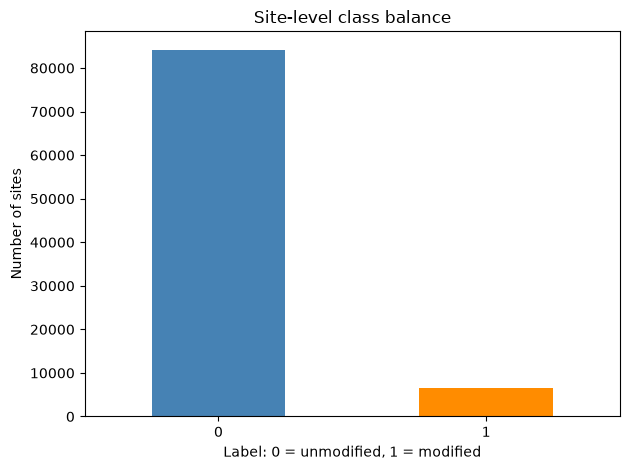

In [5]:
class_counts = (
    labelled_sites["label"]
    .value_counts()
    .reindex([0, 1], fill_value=0)
    .sort_index()
)

class_summary = pd.DataFrame({
    "sites": class_counts,
    "percentage": class_counts / class_counts.sum() * 100,
})

display(class_summary)

class_counts.plot.bar(
    color=["steelblue", "darkorange"],
    rot=0,
)

plt.xlabel("Label: 0 = unmodified, 1 = modified")
plt.ylabel("Number of sites")
plt.title("Site-level class balance")
plt.tight_layout()
plt.show()

## Original labels and transcript consistency
Inspect the preserved source labels (`label_original` when available, otherwise `label`).
These values describe the source annotation; subsequent class comparisons use binary `label`.
A shared value across many sites in one transcript should be considered when interpreting differences.

Source label column: label
Among complete multi-site transcripts, percentage with one shared source annotation value: 45.1%


count    90810.000000
mean         0.072602
std          0.259484
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: label, dtype: float64

,sites,percentage_of_nonmissing_sites
label,,
0.0,84217,92.739786
1.0,6593,7.260214


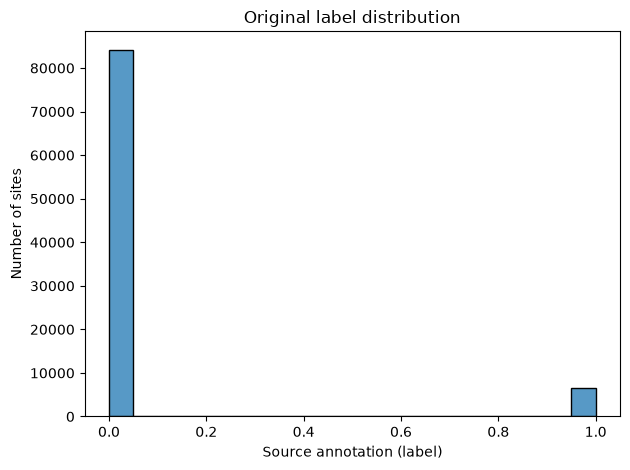

,n_sites,n_distinct_values,n_missing_values
transcript_id,,,
ENST00000000233,18,2,0
ENST00000000412,41,1,0
ENST00000001008,35,1,0
ENST00000002165,37,2,0
ENST00000005340,39,2,0
ENST00000007264,25,2,0
ENST00000007390,18,2,0
ENST00000007516,15,1,0
ENST00000009041,29,1,0


In [6]:
source_label_column = "label_original" if "label_original" in sites.columns else "label"
values = sites[source_label_column].dropna()
print(f"Source label column: {source_label_column}")
display(values.describe())
value_counts = values.value_counts().sort_index()
display(pd.DataFrame({
    "sites": value_counts,
    "percentage_of_nonmissing_sites": 100 * value_counts / value_counts.sum(),
}))
sns.histplot(values, bins=20, binrange=(0, 1))
plt.xlabel(f"Source annotation ({source_label_column})")
plt.ylabel("Number of sites")
plt.title("Original label distribution")
plt.tight_layout()
plt.show()

per_transcript = sites.groupby("transcript_id").agg(
    n_sites=("transcript_position", "size"),
    n_distinct_values=(source_label_column, "nunique"),
    n_missing_values=(source_label_column, lambda x: x.isna().sum()),
)
display(per_transcript.head(10))
eligible = per_transcript.loc[
    (per_transcript["n_sites"] > 1) & (per_transcript["n_missing_values"] == 0)
]
if not eligible.empty:
    constant_fraction = eligible["n_distinct_values"].eq(1).mean()
    print("Among complete multi-site transcripts, percentage with one shared "
          f"source annotation value: {100 * constant_fraction:.1f}%")

## Read coverage
Sites with few reads may have less stable summary statistics.

count    90810.000000
mean        87.082392
std        146.063085
min         20.000000
1%          20.000000
5%          21.000000
25%         27.000000
50%         40.000000
75%         77.000000
95%        312.000000
99%        893.000000
max        994.000000
Name: n_reads, dtype: float64

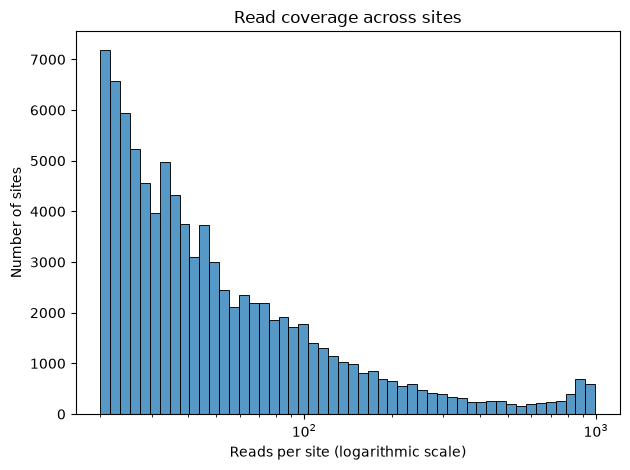

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0.0,84217.0,85.550233,144.146207,20.0,27.0,39.0,75.0,993.0
1.0,6593.0,106.653724,167.426167,20.0,29.0,47.0,96.0,994.0


In [7]:
display(
    sites["n_reads"].describe(
        percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
    )
)

sns.histplot(
    data=sites,
    x="n_reads",
    bins=50,
    log_scale=True,
)

plt.xlabel("Reads per site (logarithmic scale)")
plt.ylabel("Number of sites")
plt.title("Read coverage across sites")
plt.tight_layout()
plt.show()

display(
    labelled_sites.groupby("label")["n_reads"].describe()
)

In [8]:
# Descriptive cutoffs for EDA, not filtering rules.
coverage_summary = pd.DataFrame([
    {
        "condition": f"n_reads < {cutoff}",
        "sites": int((sites["n_reads"] < cutoff).sum()),
        "percentage": 100 * (sites["n_reads"] < cutoff).mean(),
    }
    for cutoff in [5, 10, 20]
])

display(coverage_summary)

,condition,sites,percentage
0,n_reads < 5,0,0.0
1,n_reads < 10,0,0.0
2,n_reads < 20,0,0.0


## Sites per gene ID
These are transcript-position sites, not unique genomic loci. Human datasets group by recovered
gene ID; data2 groups by synthetic RNA reference ID stored in `gene_id`.

count    3149.000000
mean       28.837726
std        23.533480
min         1.000000
25%        13.000000
50%        24.000000
75%        37.000000
max       202.000000
Name: n_sites, dtype: float64

,n_sites
gene_id,
ENSG00000087460,202
ENSG00000142864,193
ENSG00000149925,191
ENSG00000011304,189
ENSG00000184110,188


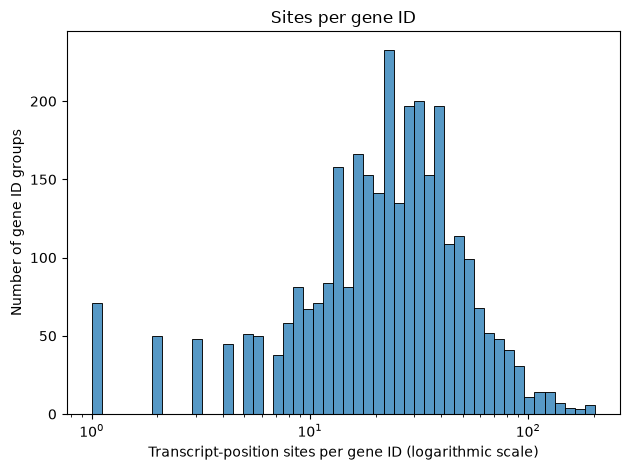

In [9]:
sites_per_gene = (
    sites.dropna(subset=["gene_id"])
    .groupby("gene_id")
    .size()
    .rename("n_sites")
    .sort_values(ascending=False)
)

display(sites_per_gene.describe())
display(sites_per_gene.head(5).to_frame())

sns.histplot(
    x=sites_per_gene,
    bins=50,
    log_scale=True,
)

plt.xlabel("Transcript-position sites per gene ID (logarithmic scale)")
plt.ylabel("Number of gene ID groups")
plt.title("Sites per gene ID")
plt.tight_layout()
plt.show()

## Sites per transcript

count    4451.000000
mean       20.402157
std        15.030846
min         1.000000
25%         9.000000
50%        17.000000
75%        28.000000
max       122.000000
Name: n_sites, dtype: float64

,n_sites
transcript_id,
ENST00000367142,122
ENST00000323853,113
ENST00000304992,111
ENST00000614672,110
ENST00000375643,106
ENST00000302516,102
ENST00000315579,101
ENST00000391975,97
ENST00000370355,94


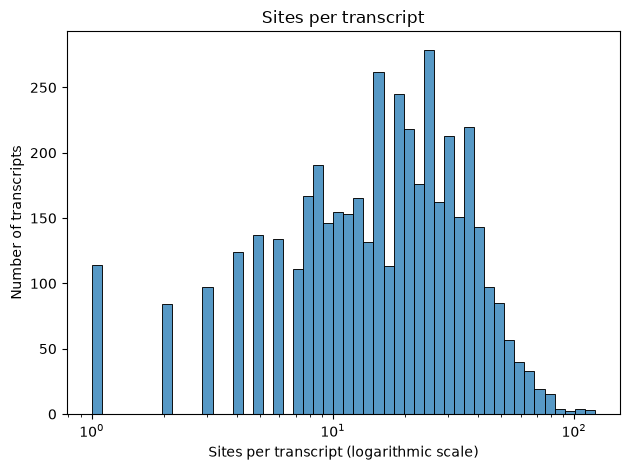

In [10]:
sites_per_transcript = (
    sites.groupby("transcript_id").size().rename("n_sites").sort_values(ascending=False)
)
display(sites_per_transcript.describe())
display(sites_per_transcript.head(10).to_frame())
sns.histplot(x=sites_per_transcript, bins=50, log_scale=True)
plt.xlabel("Sites per transcript (logarithmic scale)")
plt.ylabel("Number of transcripts")
plt.title("Sites per transcript")
plt.tight_layout()
plt.show()

## Overall 7-mer and central 5-mer frequencies

,sites
sequence,
AAAACAA,788
AGAACAA,651
AAGACCA,644
CTGACCA,644
AGGACCT,631
GAAACTG,630
CTGACCC,627
TGGACCT,627
TGGACCA,623


,sites
central_5mer,
GGACC,6562
GGACA,6514
TGACC,6270
AAACA,6216
TGACA,5886
AGACC,5778
GAACA,5699
AGACA,5459
GGACT,5415


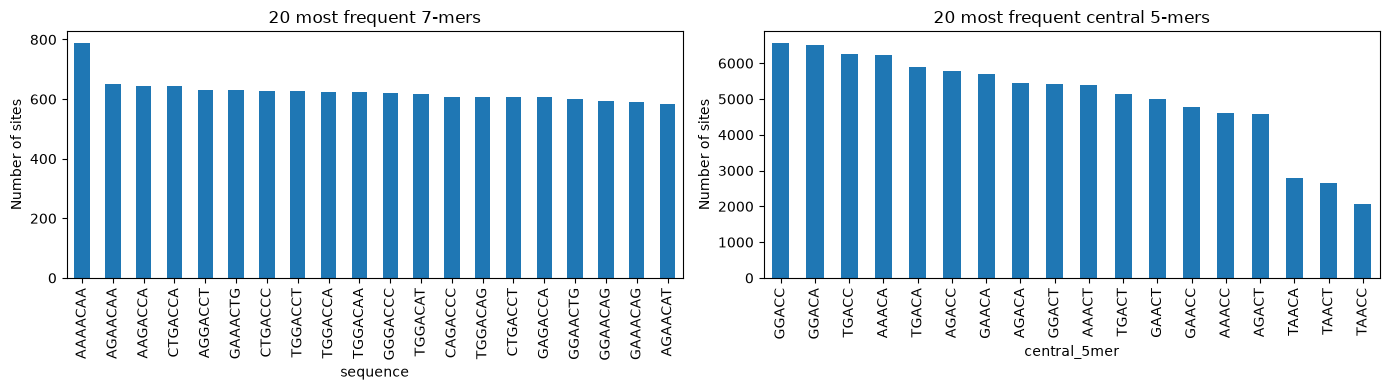

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, column, title in zip(axes, ["sequence", "central_5mer"], ["7-mers", "central 5-mers"]):
    counts = sites[column].value_counts().head(20)
    display(counts.rename("sites").to_frame())
    counts.plot.bar(ax=ax)
    ax.set_title(f"20 most frequent {title}")
    ax.set_xlabel(column)
    ax.set_ylabel("Number of sites")
plt.tight_layout()
plt.show()

## Full 7-mer freq by label
The plotted percentages use all sites in each class as the denominator, not just the top 20 sequences.

label,0,1
sequence,,
AAAACAA,766,22
AGAACAA,632,19
AAGACCA,634,10
CTGACCA,630,14
AGGACCT,574,57
GAAACTG,587,43
CTGACCC,619,8
TGGACCT,560,67
TGGACAA,566,57


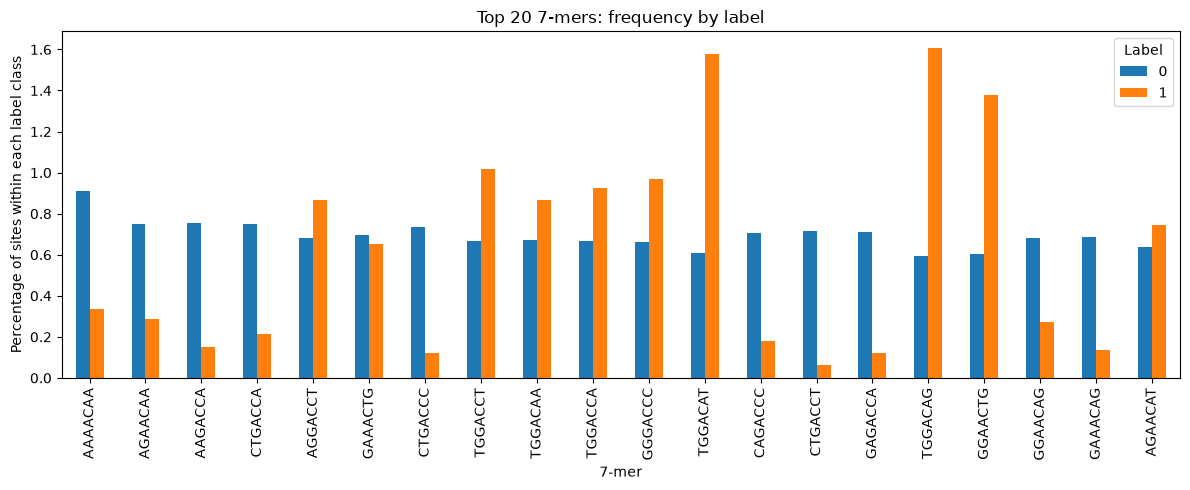

In [12]:
sequence_counts = pd.crosstab(
    labelled_sites["sequence"],
    labelled_sites["label"],
).reindex(columns=[0, 1], fill_value=0)

# Each column sums to 100% when that label class is present.
sequence_percentages = (
    sequence_counts
    .div(
        sequence_counts.sum(axis=0).replace(0, float("nan")),
        axis="columns",
    )
    * 100
)

top_sequences = (
    sequence_counts.sum(axis=1)
    .nlargest(20)
    .index
)

display(sequence_counts.loc[top_sequences])

sequence_percentages.loc[top_sequences].plot.bar(
    figsize=(12, 5),
)

plt.xlabel("7-mer")
plt.ylabel("Percentage of sites within each label class")
plt.title("Top 20 7-mers: frequency by label")
plt.legend(title="Label")
plt.tight_layout()
plt.show()

## 5-mer freq by label

label,0,1
central_5mer,,
GGACC,5998,564
GGACA,5576,938
TGACC,6170,100
AAACA,6099,117
TGACA,5674,212
AGACC,5633,145
GAACA,5327,372
AGACA,5188,271
GGACT,4229,1186


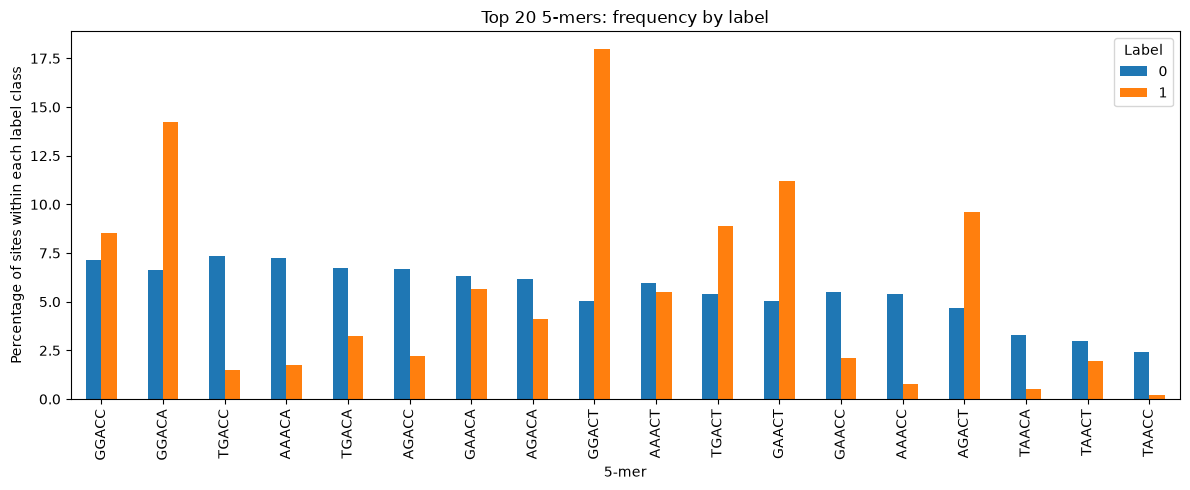

In [13]:
sequence_counts = pd.crosstab(
    labelled_sites["central_5mer"],
    labelled_sites["label"],
).reindex(columns=[0, 1], fill_value=0)

# Each column sums to 100% when that label class is present.
sequence_percentages = (
    sequence_counts
    .div(
        sequence_counts.sum(axis=0).replace(0, float("nan")),
        axis="columns",
    )
    * 100
)

top_sequences = (
    sequence_counts.sum(axis=1)
    .nlargest(20)
    .index
)

display(sequence_counts.loc[top_sequences])

sequence_percentages.loc[top_sequences].plot.bar(
    figsize=(12, 5),
)

plt.xlabel("5-mer")
plt.ylabel("Percentage of sites within each label class")
plt.title("Top 20 5-mers: frequency by label")
plt.legend(title="Label")
plt.tight_layout()
plt.show()

## Sequence motifs
Interpret positive fractions alongside site counts: a motif represented by very few sites has a less reliable estimate.

label,unmodified_sites,modified_sites,total_sites,positive_fraction
central_5mer,,,,
GGACC,5998,564,6562,0.085949
GGACA,5576,938,6514,0.143998
TGACC,6170,100,6270,0.015949
AAACA,6099,117,6216,0.018822
TGACA,5674,212,5886,0.036018
AGACC,5633,145,5778,0.025095
GAACA,5327,372,5699,0.065275
AGACA,5188,271,5459,0.049643
GGACT,4229,1186,5415,0.219021


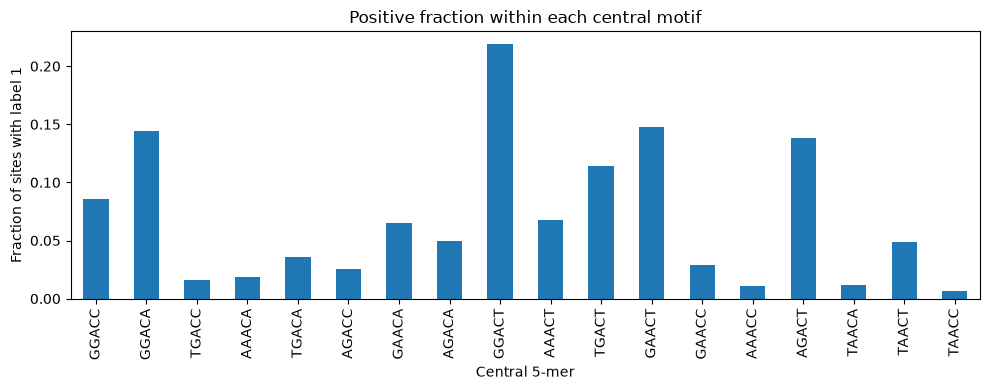

In [14]:
motif_counts = pd.crosstab(
    labelled_sites["central_5mer"],
    labelled_sites["label"],
).reindex(columns=[0, 1], fill_value=0)

motif_summary = motif_counts.rename(
    columns={0: "unmodified_sites", 1: "modified_sites"}
)

motif_summary["total_sites"] = motif_summary.sum(axis=1)

motif_summary["positive_fraction"] = (
    motif_summary["modified_sites"]
    / motif_summary["total_sites"]
)

motif_summary = motif_summary.sort_values(
    "total_sites", ascending=False
)

display(motif_summary)

motif_summary["positive_fraction"].plot.bar(
    figsize=(10, 4)
)

plt.xlabel("Central 5-mer")
plt.ylabel("Fraction of sites with label 1")
plt.title("Positive fraction within each central motif")
plt.tight_layout()
plt.show()

In [15]:
# Data-quality check to investigate unexpected motifs before deciding whether to exclude anything  
valid_motif = sites["central_5mer"].str.fullmatch(
    r"[AGT][AG]AC[ACT]",
    na=False,
)

print("Sites outside the expected DRACH motif:", (~valid_motif).sum())

display(
    sites.loc[
        ~valid_motif,
        SITE_KEYS + ["sequence", "central_5mer"]
    ].head()
)

Sites outside the expected DRACH motif: 0


,transcript_id,transcript_position,sequence,central_5mer


## Central signal features
Compare all labelled read observations by binary label. High-coverage sites contribute more
observations. Boxplots hide outliers visually; no finite observations are discarded as outliers.

central_dwell, label 0: 0 non-finite observations excluded.
central_dwell, label 1: 0 non-finite observations excluded.
central_signal_sd, label 0: 0 non-finite observations excluded.
central_signal_sd, label 1: 0 non-finite observations excluded.
central_signal_mean, label 0: 0 non-finite observations excluded.
central_signal_mean, label 1: 0 non-finite observations excluded.


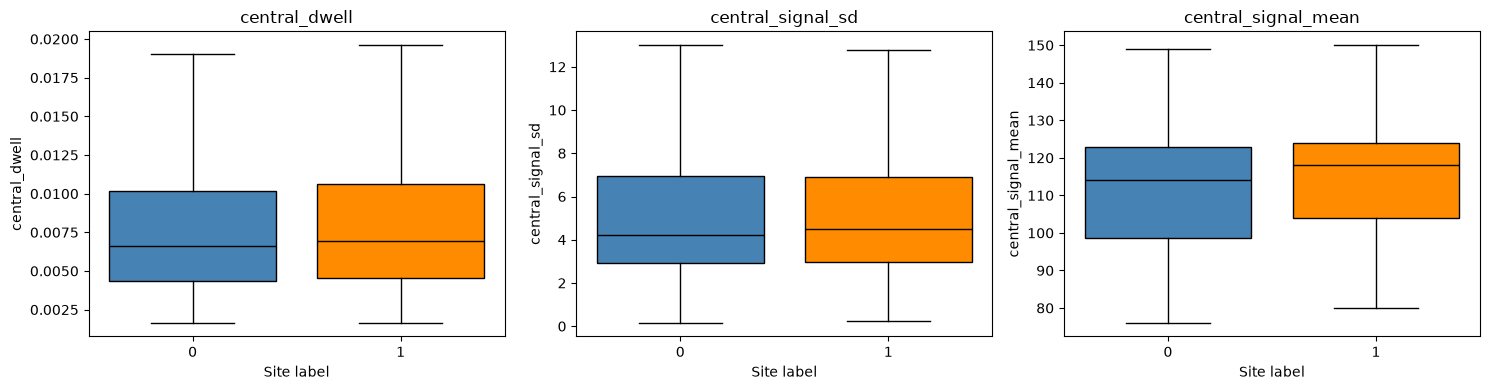

In [16]:
central_features = ["central_dwell", "central_signal_sd", "central_signal_mean"]


def plot_signal_by_label(frame, title_prefix=""):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, feature in zip(axes, central_features):
        groups, group_names = [], []
        for label in [0, 1]:
            values = pd.to_numeric(
                frame.loc[frame["label"].eq(label), feature], errors="raise",
            ).to_numpy(dtype=float, na_value=np.nan)
            finite = np.isfinite(values)
            print(f"{title_prefix}{feature}, label {label}: "
                  f"{(~finite).sum():,} non-finite observations excluded.")
            if finite.any():
                groups.append(values[finite])
                group_names.append(str(label))
        if not groups:
            ax.set_title(f"{title_prefix}{feature}: no valid observations")
            ax.axis("off")
            continue
        positions = np.arange(1, len(groups) + 1)
        box = ax.boxplot(groups, positions=positions, widths=0.8,
                         showfliers=False, patch_artist=True,
                         medianprops={"color": "black"})
        for patch, label in zip(box["boxes"], group_names):
            patch.set_facecolor({"0": "steelblue", "1": "darkorange"}[label])
        ax.set_xticks(positions)
        ax.set_xticklabels(group_names)
        ax.set_xlabel("Site label")
        ax.set_ylabel(feature)
        ax.set_title(f"{title_prefix}{feature}")
    plt.tight_layout()
    plt.show()


plot_signal_by_label(labelled_reads)

## Compare site averages
Average the read signals within each site, then attach its binary label. Each site receives
equal weight; sites from the same gene or synthetic RNA reference may still be related.

Site average: central_dwell, label 0: 0 non-finite observations excluded.
Site average: central_dwell, label 1: 0 non-finite observations excluded.
Site average: central_signal_sd, label 0: 0 non-finite observations excluded.
Site average: central_signal_sd, label 1: 0 non-finite observations excluded.
Site average: central_signal_mean, label 0: 0 non-finite observations excluded.
Site average: central_signal_mean, label 1: 0 non-finite observations excluded.


label
0.0    84217
1.0     6593
Name: sites, dtype: int64

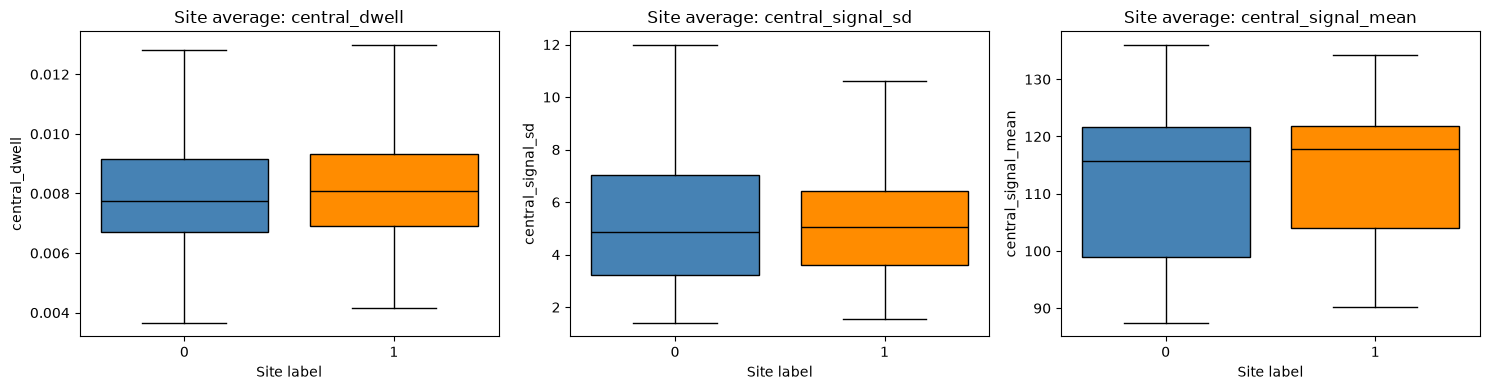

In [17]:
central_site_means = (
    labelled_reads.groupby(SITE_KEYS, as_index=False)[central_features].mean()
    .merge(labelled_sites[SITE_KEYS + ["label"]], on=SITE_KEYS, validate="one_to_one")
)
display(central_site_means.groupby("label").size().rename("sites"))
plot_signal_by_label(central_site_means, title_prefix="Site average: ")